<a href="https://colab.research.google.com/github/alexyh1/STA4000/blob/main/code/Knothe_Transport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [152]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, gamma, gaussian_kde
import time

# Generate MVN distributions
np.random.seed(4000)
n = 20000
rho_x = 0.8
rho_y = -0.8
S_1 = np.array([[1, rho_x], [rho_x, 1]])
S_2 = np.array([[1, rho_y], [rho_y, 1]])

X = np.random.multivariate_normal(-2*np.ones(2), S_1, n)
Y = np.random.multivariate_normal(4*np.ones(2), S_2, n)

In [153]:
# Step 1: Compute first marginals
X_1 = X[:, 0]
Y_1 = Y[:, 0]

def transport_1d(source, target):
    source_ecdf = stats.ecdf(source).cdf
    def T(x):
        p = source_ecdf.evaluate(x)
        return np.quantile(target, p, method="inverted_cdf")
    return T

T_1 = transport_1d(X_1, Y_1)
Y_1KR = T_1(X_1)

In [154]:
# Step 2: Conditional rearrangement
# X2 | X1 = x1 ~ N(rho_x*x1, 1-rho_x^2)
# Y2 | Y1 = y1 ~ N(rho_y*y1, 1-rho_y^2)

# CDF of X2 | X1 = x1
u = norm.cdf((X2 - rho_x*X1) / np.sqrt(1 - rho_x**2))

# Quantile of Y2 | Y1_KR = T1(x1)
Y2_KR = (rho_y * Y_1KR + np.sqrt(1 - rho_y**2) * norm.ppf(u))

T = np.column_stack((Y_1KR, Y2_KR))

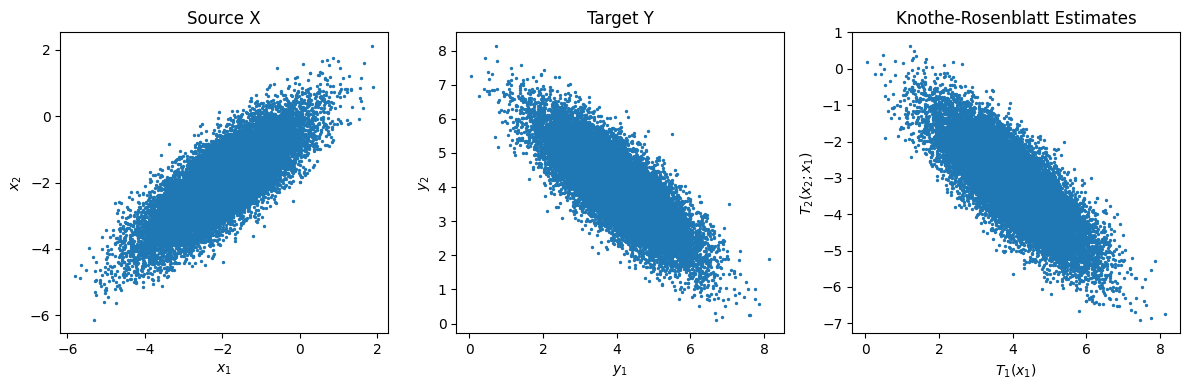

In [155]:
fig, axes = plt.subplots(1, 3, figsize = (12, 4))

axes[0].scatter(X[:,0], X[:,1], s = 2)
axes[0].set_title("Source X")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")

axes[1].scatter(Y[:,0], Y[:,1], s = 2)
axes[1].set_title("Target Y")
axes[1].set_xlabel("$y_1$")
axes[1].set_ylabel("$y_2$")

axes[2].scatter(T[:,0], T[:,1], s = 2)
axes[2].set_title("Knothe-Rosenblatt Estimates")
axes[2].set_xlabel("$T_1(x_1)$")
axes[2].set_ylabel("$T_2(x_2;x_1)$")

plt.tight_layout()
plt.show()

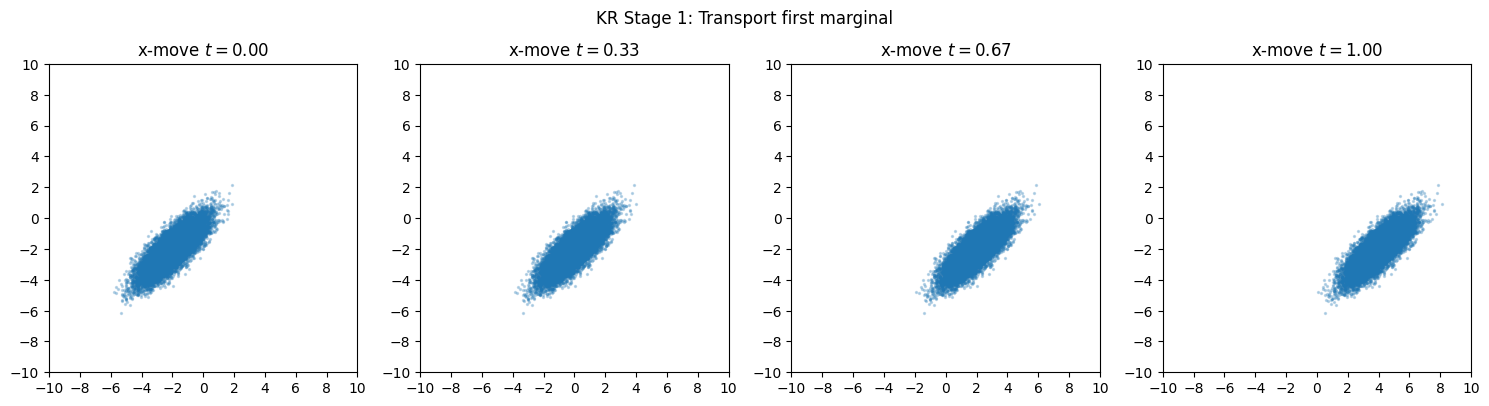

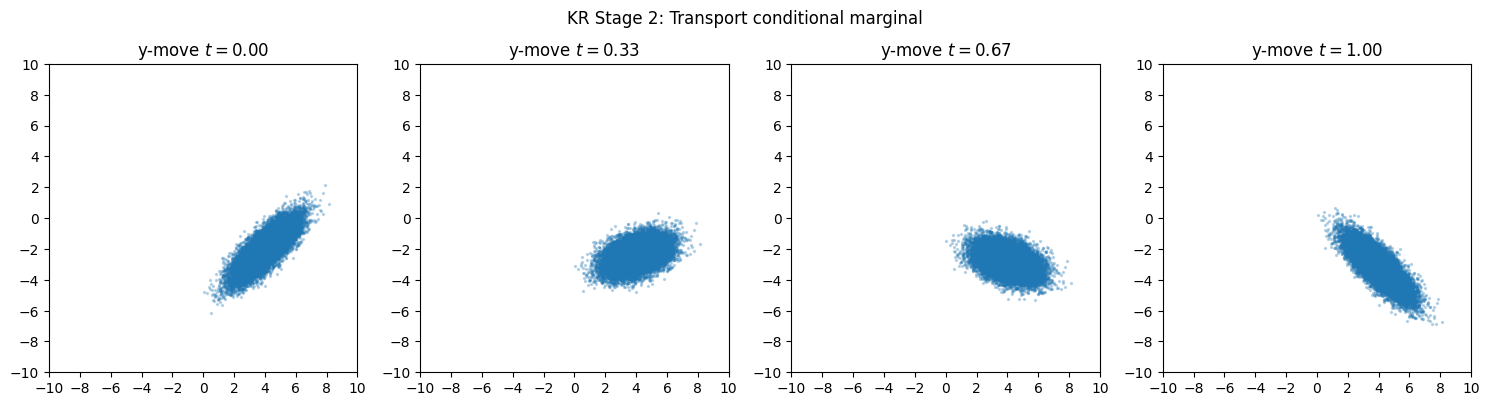

In [156]:
times = np.linspace(0, 1, num = 4)
ticks = np.arange(-10, 11, step = 2)
fig, axs = plt.subplots(1, 4, figsize = (15, 4))

for t, ax in zip(times, axs):
    Z = np.column_stack([(1-t)*X[:,0] + t*Y_1KR, X[:,1]])

    ax.scatter(Z[:,0], Z[:,1], s=2, alpha=0.25)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(f"x-move $t={t:.2f}$")

plt.suptitle("KR Stage 1: Transport first marginal")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 4, figsize=(15, 4))

for t, ax in zip(times, axs):
    Z = np.column_stack([Y_1KR, (1-t)*X[:,1] + t*Y2_KR])

    ax.scatter(Z[:,0], Z[:,1], s=2, alpha=0.25)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_title(f"y-move $t={t:.2f}$")

plt.suptitle("KR Stage 2: Transport conditional marginal")
plt.tight_layout()
plt.show()